# Customer Churn Analysis

Customer retention is a key factor in business growth, making it important to understand why customers leave. This project analyzes a telecommunications customer dataset to identify the factors influencing customer churn and uncover patterns in customer behavior. Through data cleaning, exploratory data analysis (EDA), and machine learning techniques, the project explores the relationship between customer demographics, service usage, billing information, and churn outcomes. The insights generated can help businesses develop targeted retention strategies and improve customer satisfaction.

## Importing relevant libraries

In [26]:
## Importing libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import plotly.io as pio

## Data Loading

In [27]:
## Loading the dataset 
data = pd.read_csv('Customer-Churnnn.csv')
pd.set_option('display.max_columns', None)

## 2. Data Exploration 

In [28]:
## displayinf the first 5 rows 
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
## Concise summary of the dataset 
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [30]:
## Dispaly numbers odf rows and columns 
data.shape

(7043, 21)

In [31]:
## Check for duplicates 
data.duplicated().sum()

np.int64(0)

In [32]:
## Check for missing values 
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [33]:
# descriptive summary of the dataset's numerical columns 
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [34]:
data.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

In [35]:
## changing 'TotalCharges' column to numeric 
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors= 'coerce')
data['TotalCharges'].dtype

dtype('float64')

## Data Cleaning and Preprocessing


In [36]:
## inspecting for missing values after converting 'TotalCharges' column to numeric 
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [37]:
## deleting all rows where 'TotalCharges' is missing 
data.dropna(subset=['TotalCharges'], inplace=True)

In [38]:
data['TotalCharges'].isnull().sum()

np.int64(0)

In [39]:
## descriptive summary of the dataset's numerical columns
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [40]:
## Dropping the rows with missing value. Cause they were not active clients/customers.

data = data.dropna()

In [41]:
## Checking the dataset.

data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [42]:
## Inspecting for missing values after dropping inactive client's rows.

data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Exploratory Data Analysis 

In [43]:
## Checking the number of people that churned(left).
churn_count = data['Churn'].reset_index()
churn_count

,index,Churn
0,0,No
1,1,No
2,2,Yes
3,3,No
4,4,Yes
...,...,...
7027,7038,No
7028,7039,No
7029,7040,No
7030,7041,Yes


In [44]:
## Chart showing churn.
fig = px.histogram(churn_count, x = 'Churn', title = 'Customer Churn Distribution')
fig.write_image("Customer_Churn_Distribution.png")
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
## Inspecting the contract of churned clients.

churn_contract = data.loc[(data['Churn'] == 'Yes')]['Contract'].reset_index()
churn_contract

,index,Contract
0,2,Month-to-month
1,4,Month-to-month
2,5,Month-to-month
3,8,Month-to-month
4,13,Month-to-month
...,...,...
1864,7021,One year
1865,7026,Month-to-month
1866,7032,Month-to-month
1867,7034,Month-to-month


In [ ]:

fig = px.histogram(churn_contract, x = 'Contract', title = 'Contract Distribution')
fig.write_image('Contract Distribution.png')
fig.show()

In [ ]:
churn_IS_ctrt = data.loc[(data['Churn'] == 'Yes')].groupby('InternetService')['Contract'].value_counts().reset_index()
churn_IS_ctrt

,InternetService,Contract,count
0,DSL,Month-to-month,394
1,DSL,One year,53
2,DSL,Two year,12
3,Fiber optic,Month-to-month,1162
4,Fiber optic,One year,104
5,Fiber optic,Two year,31
6,No,Month-to-month,99
7,No,One year,9
8,No,Two year,5


In [ ]:
fig = px.bar(churn_IS_ctrt, x = 'InternetService', y = 'count', color = 'Contract', text = 'count', title = 'Distribution of Internet Service by Contract')
fig.write_image('Distribution of Internet Service by Contract.png')
fig.show()

## Exploring Correlations 

In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
fig = px.scatter(data, x= 'tenure', y = 'MonthlyCharges',title= 'Relationship between MonthlyCharges and Tenure')
fig.write_image('Relationship between MonthlyCharges and Tenure.png')
fig.show()

In [ ]:
fig = px.density_heatmap(data, x='tenure', y = 'TotalCharges', title = 'Distribution of TotalCharges against Tenure')
fig.write_image('Distribution of TotalCharges against Tenure.png')
fig.show()

In [ ]:
data_encode = data.copy()

In [ ]:
data_encode.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [ ]:
data_encode.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [ ]:
num_col = data_encode.select_dtypes('number')
obj_col = data_encode.select_dtypes('object')

C:\Users\Admin\AppData\Local\Temp\ipykernel_24144\854139890.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_col = data_encode.select_dtypes('object')


In [ ]:
num_col

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [ ]:
obj_col

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


Univariate Analysis 

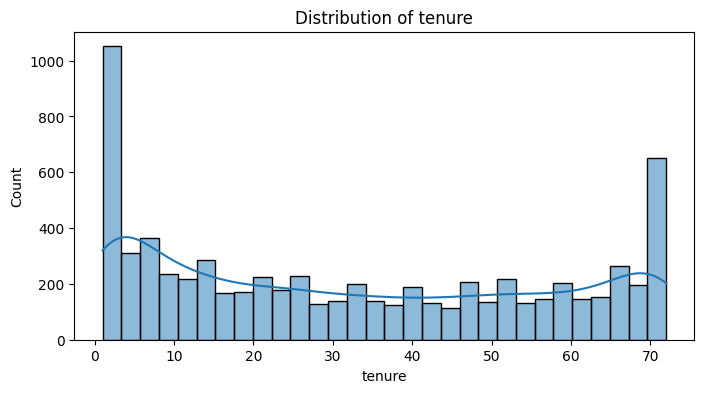

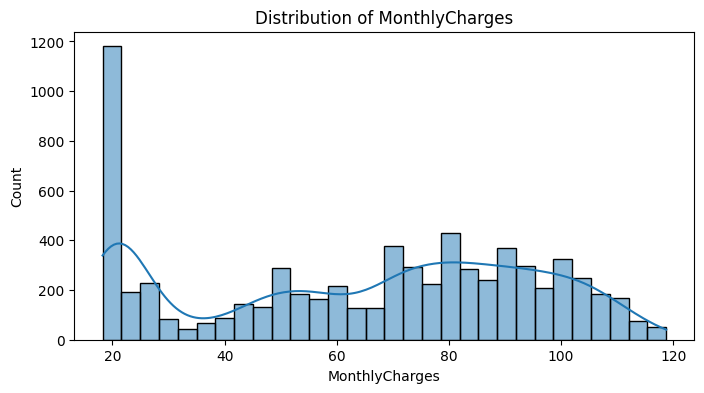

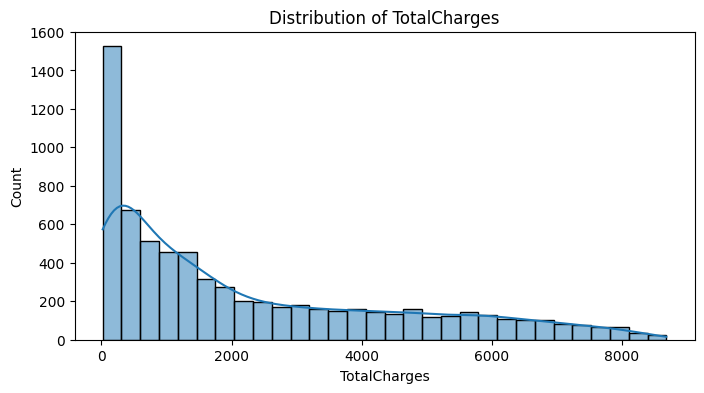

In [ ]:
# Numerical Variables Distribution 
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data[col], kde= True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'Distribution of {col}.png')
    plt.show()

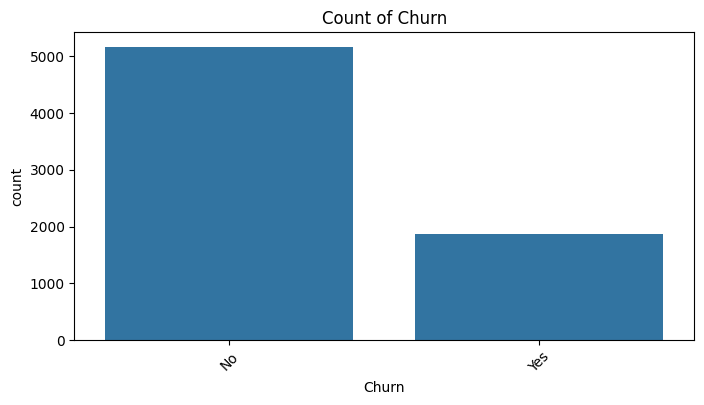

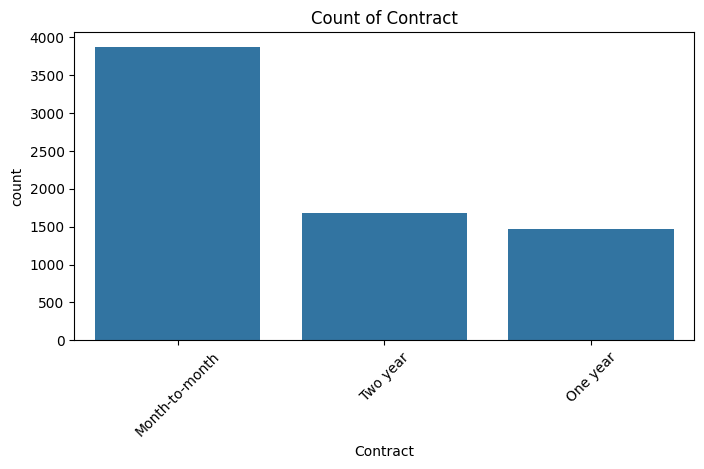

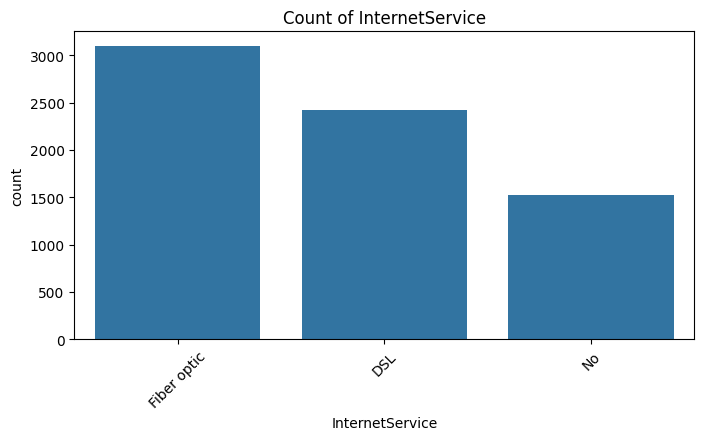

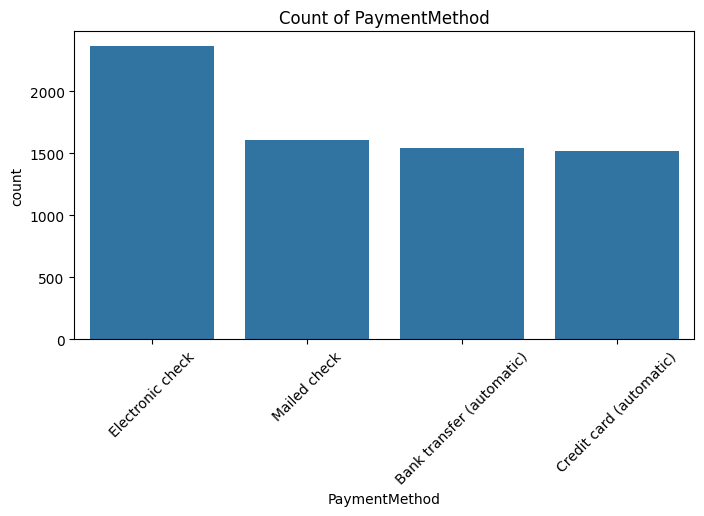

In [ ]:
# Categorical Variables Count 
cat_cols = ['Churn','Contract','InternetService','PaymentMethod']
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=data[col], order=data[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.savefig(f'Count of {col}.png')
    plt.show()

## Bivariate Analysis 
    (Relationship between two variables)

Churn vs Contract Type 

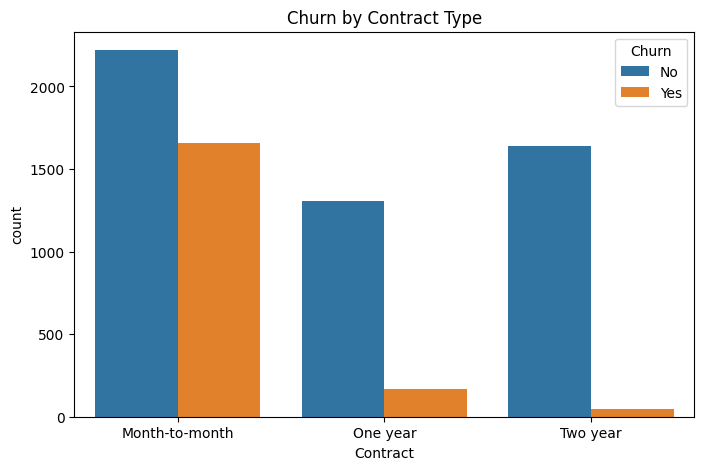

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title('Churn by Contract Type')
plt.savefig('Churn by Contract Type.png')
plt.show()

Churn vs MonthlyCharges 

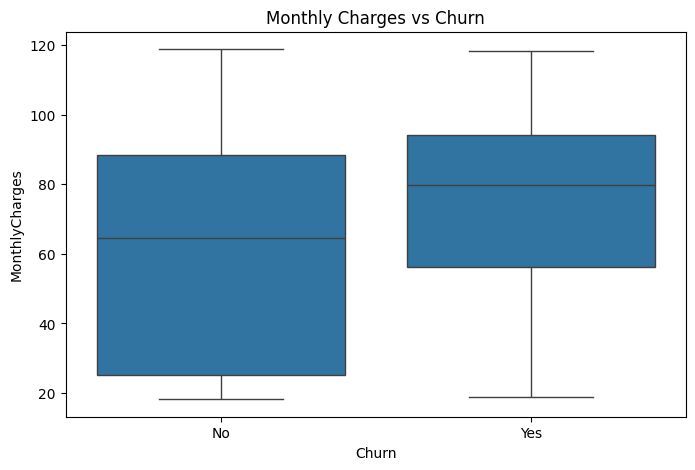

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='MonthlyCharges', data=data)
plt.title('Monthly Charges vs Churn')
plt.savefig('Monthly Charges vs Churn.png')
plt.show()

Tenure vs Total Charges 

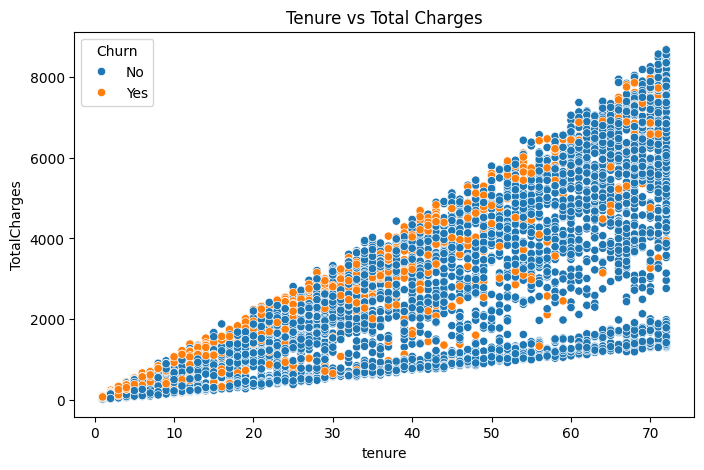

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=data)
plt.title('Tenure vs Total Charges')
plt.savefig('Tenure vs Total Charges.png')
plt.show()

## Multivariate Analysis
(Relationship among 3 or more variables)

Churn by Contract + Internet Service

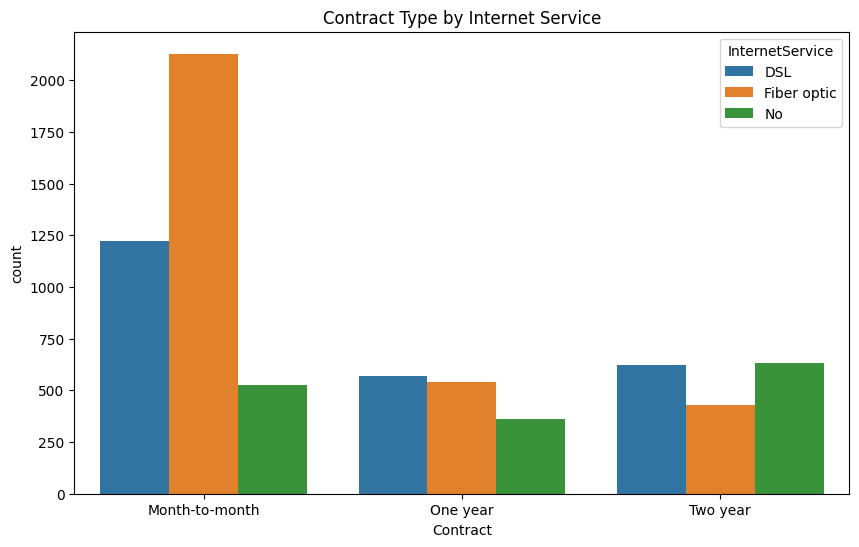

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Contract',hue='InternetService', data=data)
plt.title('Contract Type by Internet Service')
plt.savefig('Contract Type by Internet Service.png')
plt.show()

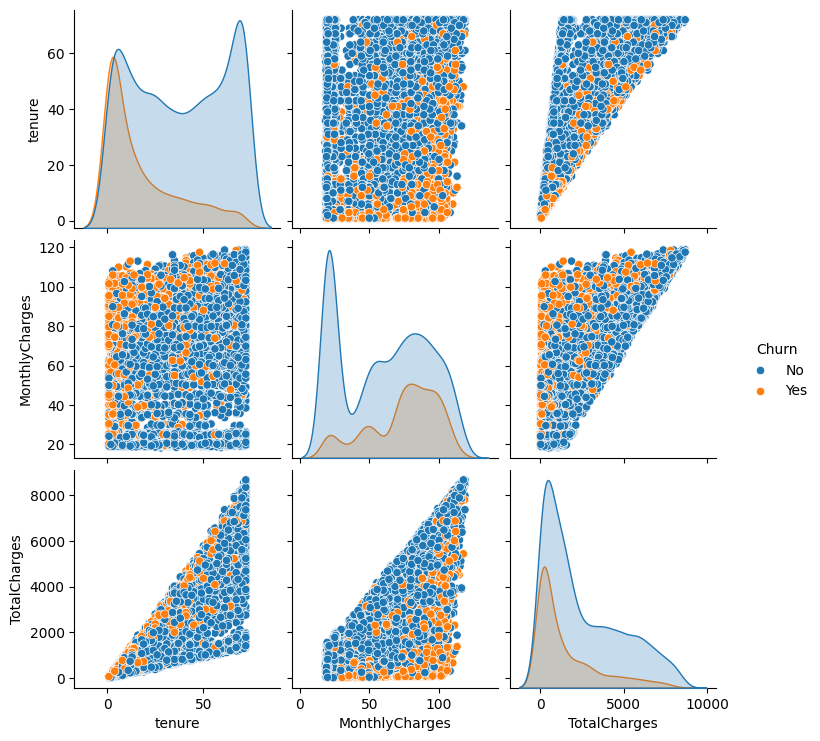

In [ ]:
sns.pairplot(data[['tenure','MonthlyCharges','TotalCharges','Churn']],hue='Churn')
plt.savefig('Correlation Among Numerical Values.png')
plt.show()

## Encoding Categorical Variables

In [ ]:
encoder = LabelEncoder()
data_encode['Partner'] = encoder.fit_transform(data_encode['Partner'])
data_encode['Dependents'] = encoder.fit_transform(data_encode['Dependents'])
data_encode['PhoneService'] = encoder.fit_transform(data_encode['PhoneService'])
data_encode['InternetService'] = encoder.fit_transform(data_encode['InternetService'])
data_encode['OnlineBackup'] = encoder.fit_transform(data_encode['OnlineBackup'])
data_encode['DeviceProtection'] = encoder.fit_transform(data_encode['DeviceProtection'])
data_encode['TechSupport'] = encoder.fit_transform(data_encode['TechSupport'])
data_encode['Contract'] = encoder.fit_transform(data_encode['Contract'])
data_encode['PaymentMethod'] = encoder.fit_transform(data_encode['PaymentMethod'])
data_encode['PaperlessBilling'] = encoder.fit_transform(data_encode['PaperlessBilling'])
data_encode['Churn'] = encoder.fit_transform(data_encode['Churn'])
data_encode['OnlineSecurity'] = encoder.fit_transform(data_encode['OnlineSecurity'])

In [ ]:
data_encode.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,0,0,2,0,0,No,No,0,1,2,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,No,0,2,0,2,0,No,No,1,0,3,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,No,0,2,2,0,0,No,No,0,1,3,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,0,2,0,2,2,No,No,1,0,0,42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,No,1,0,0,0,0,No,No,0,1,2,70.70,151.65,1


In [ ]:
Min_Max_Scale = MinMaxScaler()
data_encode[['tenure', 'MonthlyCharges', 'TotalCharges']] = Min_Max_Scale.fit_transform(data_encode[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [ ]:
data_encode.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,0.000000,0,No phone service,0,0,2,0,0,No,No,0,1,2,0.115423,0.001275,0
1,5575-GNVDE,Male,0,0,0,0.464789,1,No,0,2,0,2,0,No,No,1,0,3,0.385075,0.215867,0
2,3668-QPYBK,Male,0,0,0,0.014085,1,No,0,2,2,0,0,No,No,0,1,3,0.354229,0.010310,1
3,7795-CFOCW,Male,0,0,0,0.619718,0,No phone service,0,2,0,2,2,No,No,1,0,0,0.239303,0.210241,0
4,9237-HQITU,Female,0,0,0,0.014085,1,No,1,0,0,0,0,No,No,0,1,2,0.521891,0.015330,1


In [ ]:
data_encode.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   float64
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   int64  
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   int64  
 16  PaperlessBilling  7032 non-null   int64  
 17  PaymentMeth

In [ ]:
model_columns = ['SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

In [ ]:
X = data_encode[model_columns]
y = data_encode['Churn']

In [ ]:
X

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,1,0,0.000000,0,0,0,2,0,0,0,1,2,0.115423,0.001275
1,0,0,0,0.464789,1,0,2,0,2,0,1,0,3,0.385075,0.215867
2,0,0,0,0.014085,1,0,2,2,0,0,0,1,3,0.354229,0.010310
3,0,0,0,0.619718,0,0,2,0,2,2,1,0,0,0.239303,0.210241
4,0,0,0,0.014085,1,1,0,0,0,0,0,1,2,0.521891,0.015330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,0.323944,1,0,2,0,2,2,1,1,3,0.662189,0.227521
7039,0,1,1,1.000000,1,1,0,2,2,0,1,1,1,0.845274,0.847461
7040,0,1,1,0.140845,0,0,2,0,0,0,0,1,2,0.112935,0.037809
7041,1,1,0,0.042254,1,1,0,0,0,0,0,1,3,0.558706,0.033210


In [ ]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

## Training the model
    KNN 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 2, test_size= 0.2)

In [ ]:
knnc_model = KNeighborsClassifier()
knnc_model.fit(X_train, y_train)
knnc_pred = knnc_model.predict(X_test)
knnc_report = classification_report(y_test, knnc_pred)
print(knnc_report)

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.52      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.76      0.77      0.77      1407



In [ ]:
knnc_cm = confusion_matrix(y_test, knnc_pred)
print(knnc_cm)
knnc_model.predict_proba(X_test)

[[892 141]
 [181 193]]


array([[0.8, 0.2],
       [1. , 0. ],
       [1. , 0. ],
       ...,
       [1. , 0. ],
       [0.2, 0.8],
       [0.8, 0.2]], shape=(1407, 2))

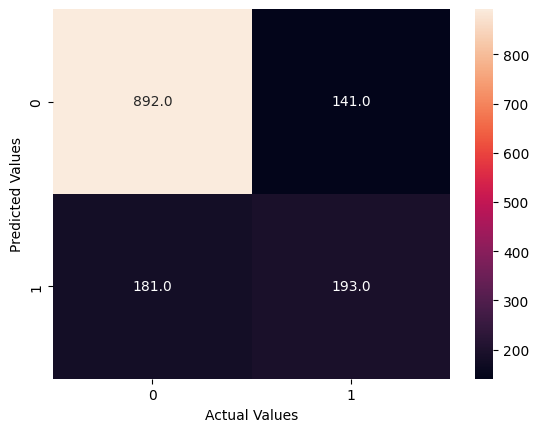

In [ ]:
sns.heatmap(knnc_cm, annot = True, fmt= '.1f')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.savefig('Heatmap showing Predicted Values against Actual Values.png')

RandomForest 

In [ ]:
dtc_model = DecisionTreeClassifier()
dtc_model.fit(X_train, y_train)
dtc_pred = dtc_model.predict(X_test)
dtc_report = classification_report(y_test, dtc_pred)
print(dtc_report)

              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1033
           1       0.47      0.49      0.48       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



In [ ]:
dtc_cm = confusion_matrix(y_test, dtc_pred)
print(dtc_cm)
dtc_model.predict_proba(X_test)

[[823 210]
 [190 184]]


array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]], shape=(1407, 2))

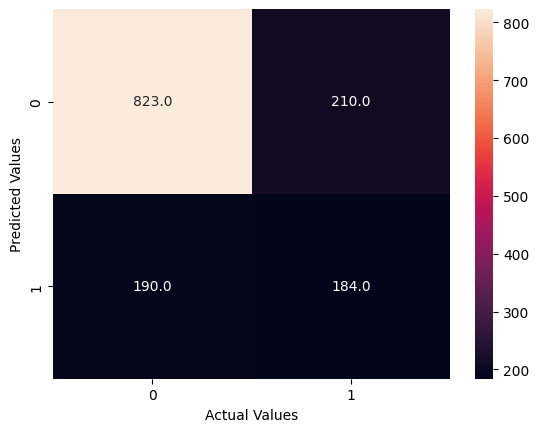

In [ ]:
sns.heatmap(dtc_cm, annot = True, fmt= '.1f')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.savefig('Decision Tree Confusion Matrix.png')

XGBoost

In [ ]:
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_report = classification_report(y_test, xgb_pred)
print(xgb_report)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [ ]:
xgb_cm = confusion_matrix(y_test, xgb_pred)
print(xgb_cm)
xgb_model.predict_proba(X_test)

[[913 120]
 [176 198]]


array([[1.0929340e-01, 8.9070660e-01],
       [9.9987286e-01, 1.2711428e-04],
       [9.9964792e-01, 3.5207742e-04],
       ...,
       [5.4843640e-01, 4.5156363e-01],
       [5.3724408e-02, 9.4627559e-01],
       [9.4048148e-01, 5.9518494e-02]], shape=(1407, 2), dtype=float32)

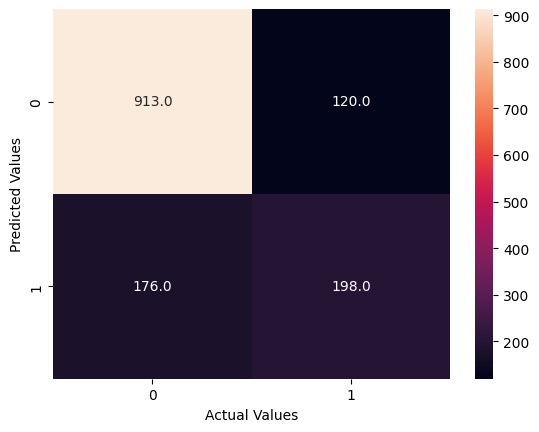

In [ ]:
sns.heatmap(xgb_cm, annot = True, fmt = '.1f')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.savefig('XGBoost Confusion Matrix.png')